<a href="https://colab.research.google.com/github/aryac-2006/Countries-Dataset-/blob/main/Heart_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [ ]:
filepath = "./heart.csv"

Q1. Load the Heart Disease dataset using pandas and display the first 10 rows. Also check the shape and basic information (info()) of the dataset.

In [ ]:
# Load the heart dataset
df = pd.read_csv(filepath)

# Display the first 10 rows
print("----------------------< First 10 Rows >-----------------------\n")
print(df.head(10))

# Display shape of the dataset
print("\n-------------------< Shape of the Datase >--------------------\n")
print(df.shape)

# Display basic information about the dataset
print("\n--------------------< Dataset Information >----------------------\n")
df.info()


----------------------< First 10 Rows >-----------------------

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDis

Q2. Check for missing values in the dataset. Show the count of null values for each column.

In [ ]:
# df.isnull().sum() :-
# Displays the number of missing values in each column

print("----------------------< Missing Values in Each Column >-----------------------\n")
print(df.isnull().sum())

----------------------< Missing Values in Each Column >-----------------------

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


Q3. Check for duplicate rows in the dataset. If any duplicates are found, remove them and print the new shape of the dataset.

In [ ]:
# count duplicate rows
dup = df.duplicated().sum()
print("Number of duplicated rows: \n", dup)

# remove duplicate rows
df.drop_duplicates(inplace=True)

# print new shape of the dataset
print("\nNew shape of the dataset after removing duplicates: \n", df.shape)

Number of duplicated rows: 
 0

New shape of the dataset after removing duplicates: 
 (918, 12)


Q4. Identify unrealistic/invalid values:
1) Count how many rows have Cholesterol = 0.
2) Count how many rows have RestingBP  0.
   Print both counts.

In [ ]:
# Count rows where cholestroal = 0
cho = (df["Cholesterol"] == 0).sum()
print("Number of rows with Cholesterol = 0: \n", cho)

# Count rows where RestingBP  = 0
bp = (df["RestingBP"] == 0).sum()
print("\nNumber of rows with RestingBP = 0: \n", bp)

Number of rows with Cholesterol = 0: 
 172

Number of rows with RestingBP = 0: 
 1


Q5. Clean the invalid values:
1) Replace Cholesterol = 0 with the mean cholesterol value (excluding zeros).

2) Replace RestingBP  0 with the mean resting blood pressure value(excluding zeros).
3) Round both columns to 2 decimal places.

Print the statistical summary (describe()) of these two columns before and after cleaning.

In [ ]:
# Statistical summary before cleaning
print("-------------< Statistical Summary Before Cleaning >------------\n")
print(df[["Cholesterol", "RestingBP"]].describe())

# Calculate mean excluding zero values
mean_chol = df[df["Cholesterol"] != 0]
meam = mean_chol["Cholesterol"].mean()

mean_BP = df[df["RestingBP"] != 0]
mean = mean_BP["RestingBP"].mean()

# Replace 0 values with mean
df["Cholesterol"] = df["Cholesterol"].replace(0, mean)
df["RestingBP"] = df["RestingBP"].replace(0, mean)

# Round both columns to 2 decimal places
df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

# Statistical summary after cleaning
print("\n--------------< Statistical Summary After Cleaning >-------------\n")
print(df[["Cholesterol", "RestingBP"]].describe())

-------------< Statistical Summary Before Cleaning >------------

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    223.632767  132.540893
std      68.978877   17.989932
min      85.000000   80.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

--------------< Statistical Summary After Cleaning >-------------

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    223.632767  132.540893
std      68.978877   17.989932
min      85.000000   80.000000
25%     173.250000  120.000000
50%     223.000000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


Q6. Create a function to plot histograms for the following numerical columns:
1) Age

2) RestingBP

3) Cholesterol

4) MaxHR

  Plot all four histograms in one figure using subplots 2 2 layout). Use this function to visualize the data after cleaning.

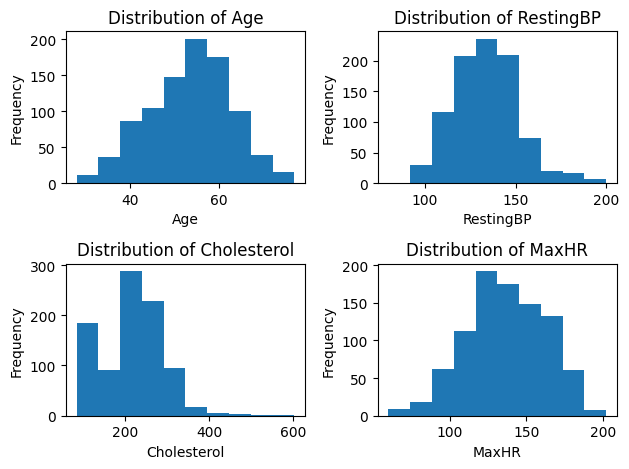

In [ ]:
# Function to plot histograms
def plot_histograms(pos, column):
   plt.subplot(2, 2, pos)
   plt.hist(df[column])
   plt.title(f"Distribution of {column}")
   plt.xlabel(column)
   plt.ylabel("Frequency")

# plot all four histogram
plot_histograms(1, "Age")
plot_histograms(2, "RestingBP")
plot_histograms(3, "Cholesterol")
plot_histograms(4, "MaxHR")
plt.tight_layout()
plt.show()

Q7. Identify and print numerical columns and categorical columns separately.

In [ ]:
# print numerical columns separately.
print("======== Numerical Columns ========\n")
for col in df.columns:
    if df[col].dtype != "object":
        print(col)

# print categorical columns separately.
print("\n======== Categorical Columns ========\n")
for col in df.columns:
    if df[col].dtype == "object":
        print(col)

======== Numerical Columns ========

Age
RestingBP
Cholesterol
FastingBS
MaxHR
Oldpeak
HeartDisease

======== Categorical Columns ========

Sex
ChestPainType
RestingECG
ExerciseAngina
ST_Slope


Q8. Perform One-Hot Encoding on all categorical columns using

pd.get_dummies().

Store the result in a new dataframe called df_encoded.
  
Print the shape and the first 5 rows of the encoded dataframe.

In [ ]:
# Perform One-Hot Encoding on all categorical columns$0
df_encoded = pd.get_dummies(df)

# Print the shape
print("---------- Shape of Encoded DataFrame ---------\n")
print(df_encoded.shape)

# First 5 rows of the encoded dataframe
print("\n---------- First 5 rows of Encoded DataFrame ---------\n")
print(df_encoded.head())

---------- Shape of Encoded DataFrame ---------

(918, 21)

---------- First 5 rows of Encoded DataFrame ---------

   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              Fals

Q9. After cleaning and encoding:

Print the final shape of df_encoded.

Show the list of all column names in the final dataframe.


In [ ]:
print("---------- Final Shape of Encoded DataFrame ---------\n")
print(df_encoded.shape)

print("\n---------- List of All Column Names ---------\n")
print(df_encoded.columns)

---------- Final Shape of Encoded DataFrame ---------

(918, 21)

---------- List of All Column Names ---------

Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


Q10. Summary) Write a short summary (in comments or markdown) covering:

 What invalid values did you find and how did you fix them?

 Why is it important to handle invalid values like Cholesterol = 0?

  What is the purpose of One-Hot Encoding?
  
  Any other observations from the cleaning process

In [ ]:
# Summary

# 1. Invalid values found and how they were fixed:
#    - Found rows where Cholesterol = 0 and RestingBP = 0.
#    - Replaced these invalid values with the mean of the respective columns
#      (excluding the zero values).

# 2. Importance of handling invalid values:
#    - Invalid values can affect statistical analysis and machine learning models.
#    - Replacing them with the mean improves data quality and accuracy.

# 3. Purpose of One-Hot Encoding:
#    - One-Hot Encoding converts categorical columns into numerical (0/1) columns.
#    - This allows machine learning algorithms to process categorical data.

# 4. Other observations:
#    - Missing values and duplicate rows were checked and handled.
#    - The dataset became cleaner and ready for analysis and model building.